In [ ]:

%cd /content/drive/MyDrive/Final/Data/감정

/content/drive/MyDrive/Final/Data/감정


# 불러오기

In [ ]:
from tqdm import tqdm
import pandas as pd

import re
from ast import literal_eval


In [ ]:
import pandas as pd

df = pd.read_csv("./LDA_Actor_Action_cluster_integrated.csv", encoding="utf-8-sig")
df.head()





,Unnamed: 0.1,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,tokenized,actor_cluster,action_cluster
0,0,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...",0,1
1,1,8,네이버카페_맘이베베,육아질문방,원래 둘째 임신이 더 힘든거에요,찻째 때는 임신 증상 하나도 없었는데 둘째는 입덧 먹덧 허리통증 환도통증 미칠거같네...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '...",0,1
2,2,12,네이버카페_맘이베베,육아질문방,주차인데 선홍색 피비침 화유일까요,월에도 화유했는데 너무 불안하네요 아침에 눈떠서 소변보는데 피가살짝 비쳐서 일단 출...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',...",0,1
3,3,15,네이버카페_맘이베베,육아질문방,임당은 몇주에가서 검사하나요,지금 주인데 주 일에 정밀초음파보려가요 임당은 몇주부터 몇주까지 검사하려가야하나요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']",0,2
4,4,24,네이버카페_맘이베베,육아질문방,인기없는 원장님은 이유가 있네요,간밤에 복통와 출혈로 글썼던 경산모입니다 제가 딱 년전 작년 월에 미즈 에서 다발성...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰...",0,2


# 전처리 (완)

- 7개의 감정을 positive와 negative로 묶어 binary화
- 5명의 태거가

In [ ]:
df.head()

,발화문,1번 감정,1번 감정세기,2번 감정,2번 감정세기,3번 감정,3번 감정세기,4번 감정,4번감정세기,5번 감정,5번 감정세기,Neg sum,Pos sum
0,"어, 청소 니가 대신 해 줘!",Pos,0,Neg,1,Pos,0,Pos,0,Neg,1,2,0
1,둘 다 청소 하기 싫어. 귀찮아.,Pos,0,Neg,1,Pos,0,Pos,0,Neg,1,2,0
2,둘 다 하기 싫어서 화내.,Neg,1,Neg,1,Pos,0,Neg,1,Neg,1,4,0
3,그럼 방세는 어떡해.,Neg,1,Neg,1,Neg,1,Neg,1,Neg,1,5,0
4,권태긴줄 알았는데 다른 사람이 생겼나보더라고.,Neg,1,Neg,1,Neg,1,Neg,2,Neg,1,6,0


In [ ]:
import pandas as pd


# 부정 감정 목록 정의
neg_labels = ['angry', 'disgust', 'sadness', 'fear']

# 감정 열과 세기 열의 쌍 정의 (4번 감정세기 열의 공백 유무 주의)
emotion_cols = ['1번 감정', '2번 감정', '3번 감정', '4번 감정', '5번 감정']
intensity_cols = ['1번 감정세기', '2번 감정세기', '3번 감정세기', '4번감정세기', '5번 감정세기']

# 합계 열 초기화
df['Neg sum'] = 0
df['Pos sum'] = 0

for e_col, s_col in zip(emotion_cols, intensity_cols):
    # 감정 문자열을 소문자로 변환하여 비교 (대소문자 구분 방지)
    is_neg = df[e_col].str.lower().isin(neg_labels)

    # Neg와 Pos에 해당하는 행의 세기 값을 합산
    df.loc[is_neg, 'Neg sum'] += df.loc[is_neg, s_col]
    df.loc[~is_neg, 'Pos sum'] += df.loc[~is_neg, s_col]

    # 감정 레이블을 'Neg' 또는 'Pos'로 변경
    df[e_col] = df[e_col].apply(lambda x: 'Neg' if str(x).lower() in neg_labels else 'Pos')



In [ ]:
len(df)

14606

# "nlp04/korean_sentiment_analysis_kcelectra"

In [ ]:

from transformers import pipeline

pipe = pipeline("text-classification", model="nlp04/korean_sentiment_analysis_kcelectra")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/511M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: nlp04/korean_sentiment_analysis_kcelectra
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/511M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
result = pipe("아 진짜 먹기 싫다")[0]
lab = result['label']
sc = result['score']
print(lab, sc)




짜증남 0.6227898597717285


In [ ]:
lab_list = []
sc_list = []

for text in tqdm(df['내용']):
    try:
        # 2. truncation=True 옵션을 추가하여 최대 길이를 넘는 텍스트를 자동으로 자릅니다.
        result = pipe(text, truncation=True)[0]

        lab = result['label']
        sc = result['score']
        lab_list.append(lab)
        sc_list.append(sc)
    except Exception as e:
        # 에러가 발생할 경우 리스트의 길이를 맞추기 위해 None이나 예외 처리를 해주는 것이 안전합니다.
        lab_list.append(None)
        sc_list.append(None)
        print(f"Error processing text: {e}")

# 결과 반영
df['감성 카테고리'] = lab_list
df['감성점수'] = sc_list

100%|██████████| 58314/58314 [13:39<00:00, 71.17it/s]


In [ ]:
sentiment_mapping = {
    '짜증남': -1,
    '걱정스러운(불안한)': -1,
    '슬픔(우울한)': -1,
    '힘듦(지침)': -1,
    '생각이 많은': -1,
    '사랑하는': 1,
    '기쁨(행복한)': 1,
    '일상적인': 1,
    '고마운': 1,
    '설레는(기대하는)': 1,
    '즐거운(신나는)': 1
}

# 기존 카테고리 열을 기반으로 새로운 점수 열 생성
df['카테고리_점수'] = df['감성 카테고리'].map(sentiment_mapping)

In [ ]:
df['sentiments_score'] = df['감성점수'] * df['카테고리_점수']


In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,tokenized,actor_cluster,action_cluster,감성 카테고리,감성점수,카테고리_점수,sentiments_score
0,0,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...",0,1,걱정스러운(불안한),0.499795,-1,-0.499795
1,1,8,네이버카페_맘이베베,육아질문방,원래 둘째 임신이 더 힘든거에요,찻째 때는 임신 증상 하나도 없었는데 둘째는 입덧 먹덧 허리통증 환도통증 미칠거같네...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '...",0,1,슬픔(우울한),0.845240,-1,-0.845240
2,2,12,네이버카페_맘이베베,육아질문방,주차인데 선홍색 피비침 화유일까요,월에도 화유했는데 너무 불안하네요 아침에 눈떠서 소변보는데 피가살짝 비쳐서 일단 출...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',...",0,1,걱정스러운(불안한),0.986264,-1,-0.986264
3,3,15,네이버카페_맘이베베,육아질문방,임당은 몇주에가서 검사하나요,지금 주인데 주 일에 정밀초음파보려가요 임당은 몇주부터 몇주까지 검사하려가야하나요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']",0,2,걱정스러운(불안한),0.866364,-1,-0.866364
4,4,24,네이버카페_맘이베베,육아질문방,인기없는 원장님은 이유가 있네요,간밤에 복통와 출혈로 글썼던 경산모입니다 제가 딱 년전 작년 월에 미즈 에서 다발성...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰...",0,2,슬픔(우울한),0.522165,-1,-0.522165


In [ ]:
df.to_csv("LDA_Actor_Action_cluster_integrated.csv", encoding = "utf-8-sig")

# koelectra-base-v3-generalized-sentiment-analysis

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline

# load model
tokenizer = AutoTokenizer.from_pretrained("Copycats/koelectra-base-v3-generalized-sentiment-analysis")
model = AutoModelForSequenceClassification.from_pretrained("Copycats/koelectra-base-v3-generalized-sentiment-analysis")
sentiment_classifier = TextClassificationPipeline(tokenizer=tokenizer, model=model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/452M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: Copycats/koelectra-base-v3-generalized-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
sentiment_classifier("내가 애정 표현을 잘 못해서 자주 싸우긴 했어.")

[{'label': '0', 'score': 0.5064628720283508}]

In [ ]:
lab_list = []
sc_list = []

for text in tqdm(df['발화문']):
  result = sentiment_classifier(text)[0]
  lab = result['label']
  sc = result['score']
  lab_list.append(lab)
  sc_list.append(sc)

df['카테고리_koelect'] = lab_list
df['점수_koelect'] = sc_list


# https://huggingface.co/Copycats/koelectra-base-v3-generalized-sentiment-analysis

100%|██████████| 14606/14606 [02:19<00:00, 105.00it/s]


In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,발화문,1번 감정,1번 감정세기,2번 감정,2번 감정세기,3번 감정,3번 감정세기,4번 감정,4번감정세기,5번 감정,5번 감정세기,Neg sum,Pos sum,카테고리,점수,카테고리_koelect,점수_koelect
0,0,0,"어, 청소 니가 대신 해 줘!",Pos,0,Neg,1,Pos,0,Pos,0,Neg,1,2,0,짜증남,0.981865,1,0.734883
1,1,1,둘 다 청소 하기 싫어. 귀찮아.,Pos,0,Neg,1,Pos,0,Pos,0,Neg,1,2,0,짜증남,0.986563,0,0.907762
2,2,2,둘 다 하기 싫어서 화내.,Neg,1,Neg,1,Pos,0,Neg,1,Neg,1,4,0,짜증남,0.983428,0,0.706632
3,3,3,그럼 방세는 어떡해.,Neg,1,Neg,1,Neg,1,Neg,1,Neg,1,5,0,걱정스러운(불안한),0.878020,0,0.825981
4,4,4,권태긴줄 알았는데 다른 사람이 생겼나보더라고.,Neg,1,Neg,1,Neg,1,Neg,2,Neg,1,6,0,슬픔(우울한),0.784388,0,0.579552


In [ ]:
import pandas as pd

# 1. 텍스트 카테고리를 -1과 1로 매핑
# '카테고리' 열의 이름을 실제 데이터프레임의 열 이름으로 수정하여 사용하십시오.
sentiment_mapping = {
    '짜증남': -1,
    '걱정스러운(불안한)': -1,
    '슬픔(우울한)': -1,
    '힘듦(지침)': -1,
    '생각이 많은': -1,
    '사랑하는': 1,
    '기쁨(행복한)': 1,
    '일상적인': 1,
    '고마운': 1,
    '설레는(기대하는)': 1,
    '즐거운(신나는)': 1
}

# 기존 카테고리 열을 기반으로 새로운 점수 열 생성
df['카테고리_점수'] = df['카테고리'].map(sentiment_mapping)

# 2. 카테고리_koelect 열에서 0을 -1로 변경
df['카테고리_koelect'] = df['카테고리_koelect'].replace(0, -1)



In [ ]:


# 1-4. 열 이름 변경
df = df.rename(columns={
    '점수': '점수_kc',
    '카테고리_koelect': '카테고리_ko',
    '점수_koelect': '점수_ko',
    '카테고리_점수': '카테고리_kc'
})

# 5. 열 순서 변경
df = df[['점수_kc', '카테고리_kc', '점수_ko', '카테고리_ko']]

# 6. 카테고리 열 타입 변경 (int)
df['카테고리_kc'] = df['카테고리_kc'].astype(int)
df['카테고리_ko'] = df['카테고리_ko'].astype(int)

df['카테고리_ko'] = df['카테고리_ko'].replace(0, -1)
# 7. 최종 점수 열 생성 (점수 * 카테고리)
df['최종_kc'] = df['점수_kc'] * df['카테고리_kc']
df['최종_ko'] = df['점수_ko'] * df['카테고리_ko']

df.head()

,점수_kc,카테고리_kc,점수_ko,카테고리_ko,최종_kc,최종_ko
0,0.981865,-1,0.734883,1,-0.981865,0.734883
1,0.986563,-1,0.907762,-1,-0.986563,-0.907762
2,0.983428,-1,0.706632,-1,-0.983428,-0.706632
3,0.878020,-1,0.825981,-1,-0.878020,-0.825981
4,0.784388,-1,0.579552,-1,-0.784388,-0.579552


In [ ]:
df.to_csv("kc수정.csv", encoding = "utf-8-sig")

# 감성사전


In [ ]:
import json

In [ ]:
from tqdm.auto import tqdm
from itertools import pairwise
import pandas as pd

tqdm.pandas()

def tokenize_and_stem(text):
    if not isinstance(text, str) or not text.strip():
        return [], []

    tokens = kiwi.tokenize(text)
    target_tags = {'NNG', 'NNP', 'VV', 'VA'}

    extracted_tokens = []
    for token in tokens:
        if token.tag in target_tags:
            t = token.lemma if token.tag in {'VV', 'VA'} else token.form
            if t not in stopwords:
                extracted_tokens.append(t)

    bigrams = [f"{a}_{b}" for a, b in pairwise(extracted_tokens)]
    return extracted_tokens, bigrams

# progress_apply를 사용하여 진행바 표시
# 결과물은 리스트 형태이므로 다시 DataFrame으로 확장
results = df['발화문'].progress_apply(tokenize_and_stem)

# 결과를 각각의 컬럼에 할당
df[['tagged_review', 'bigram']] = pd.DataFrame(results.tolist(), index=df.index)

# 결과 확인
df.head()

  0%|          | 0/14606 [00:00<?, ?it/s]

,Unnamed: 0.1,Unnamed: 0,발화문,1번 감정,1번 감정세기,2번 감정,2번 감정세기,3번 감정,3번 감정세기,4번 감정,...,5번 감정,5번 감정세기,Neg sum,Pos sum,카테고리,점수,카테고리_koelect,점수_koelect,tagged_review,bigram
0,0,0,"어, 청소 니가 대신 해 줘!",Pos,0,Neg,1,Pos,0,Pos,...,Neg,1,2,0,짜증남,0.981865,짜증남,0.981865,"[청소, 대신]",[청소_대신]
1,1,1,둘 다 청소 하기 싫어. 귀찮아.,Pos,0,Neg,1,Pos,0,Pos,...,Neg,1,2,0,짜증남,0.986563,짜증남,0.986563,"[청소, 싫다, 귀찮다]","[청소_싫다, 싫다_귀찮다]"
2,2,2,둘 다 하기 싫어서 화내.,Neg,1,Neg,1,Pos,0,Neg,...,Neg,1,4,0,짜증남,0.983428,짜증남,0.983428,"[싫다, 화내다]",[싫다_화내다]
3,3,3,그럼 방세는 어떡해.,Neg,1,Neg,1,Neg,1,Neg,...,Neg,1,5,0,걱정스러운(불안한),0.878020,걱정스러운(불안한),0.878020,[방세],[]
4,4,4,권태긴줄 알았는데 다른 사람이 생겼나보더라고.,Neg,1,Neg,1,Neg,1,Neg,...,Neg,1,6,0,슬픔(우울한),0.784388,슬픔(우울한),0.784388,"[권태기, 알다, 사람, 생기다]","[권태기_알다, 알다_사람, 사람_생기다]"


In [ ]:
with open("SentiWord_info.json", mode = 'r', encoding="utf-8") as f:
  sent_dict = json.load(f)

In [ ]:
sent_df = pd.DataFrame(sent_dict)
sent_df['polarity'].value_counts()

,count
polarity,
-1,5030
-2,4799
2,2602
1,2269
0,154


In [ ]:
def sentiment_score(sent_dict, token_list):
  result_list = []
  for token in token_list:
    for s in sent_dict:
      if s['word'] == token :
        result = s['word'], s['polarity']
        result_list.append(result)
  return result_list

  sentiment_score(sent_dict, df['tagged_review'][1])

In [ ]:
 sentiment_score(sent_dict, df['tagged_review'][1])

[('싫다', '-2'), ('귀찮다', '-1')]

In [ ]:
!pip install konlpy
!pip install kiwipiepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 24.4 MB/s eta 0:00:00


In [ ]:
from konlpy.tag import Okt
okt=Okt()

from kiwipiepy import Kiwi
kiwi = Kiwi()

In [ ]:
def okt_pos_tagging(string):
  string = kiwi.space(string)
  pos_words = okt.morphs(string, stem=True, norm = True)
  return pos_words

In [ ]:
sentiment = []
for i in tqdm(df['발화문']):
  token = okt_pos_tagging(i)
  score = sentiment_score(sent_dict, token)
  sentiment.append(score)

avg_sents = []

for sents in tqdm(sentiment) :
  sents_score = sum([int(i[1]) for i in sents])
  avg_sents.append(sents_score)

  0%|          | 0/14606 [00:00<?, ?it/s]

  0%|          | 0/14606 [00:00<?, ?it/s]

In [ ]:
df['sentiments_score'] = avg_sents
df

,Unnamed: 0.1,Unnamed: 0,발화문,1번 감정,1번 감정세기,2번 감정,2번 감정세기,3번 감정,3번 감정세기,4번 감정,...,5번 감정세기,Neg sum,Pos sum,카테고리,점수,카테고리_koelect,점수_koelect,tagged_review,bigram,sentiments_score
0,0,0,"어, 청소 니가 대신 해 줘!",Pos,0,Neg,1,Pos,0,Pos,...,1,2,0,짜증남,0.981865,짜증남,0.981865,"[청소, 대신]",[청소_대신],0
1,1,1,둘 다 청소 하기 싫어. 귀찮아.,Pos,0,Neg,1,Pos,0,Pos,...,1,2,0,짜증남,0.986563,짜증남,0.986563,"[청소, 싫다, 귀찮다]","[청소_싫다, 싫다_귀찮다]",-3
2,2,2,둘 다 하기 싫어서 화내.,Neg,1,Neg,1,Pos,0,Neg,...,1,4,0,짜증남,0.983428,짜증남,0.983428,"[싫다, 화내다]",[싫다_화내다],-2
3,3,3,그럼 방세는 어떡해.,Neg,1,Neg,1,Neg,1,Neg,...,1,5,0,걱정스러운(불안한),0.878020,걱정스러운(불안한),0.878020,[방세],[],-2
4,4,4,권태긴줄 알았는데 다른 사람이 생겼나보더라고.,Neg,1,Neg,1,Neg,1,Neg,...,1,6,0,슬픔(우울한),0.784388,슬픔(우울한),0.784388,"[권태기, 알다, 사람, 생기다]","[권태기_알다, 알다_사람, 사람_생기다]",-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,14601,14601,"아, 요즘 룸메랑 너무 자주 싸우게 돼.",Neg,1,Neg,2,Neg,1,Neg,...,1,6,0,힘듦(지침),0.810980,힘듦(지침),0.810980,"[요즘, 룸메, 싸우다]","[요즘_룸메, 룸메_싸우다]",-2
14602,14602,14602,"아, 룸메가 방을 너무 지저분하게 써. 음식물도 막 버리고.",Neg,1,Neg,2,Neg,1,Neg,...,1,6,0,짜증남,0.979594,짜증남,0.979594,"[룸메, 방, 쓰다, 음식물, 버리다]","[룸메_방, 방_쓰다, 쓰다_음식물, 음식물_버리다]",-4
14603,14603,14603,"뭐 화를 낸 것까진 아니지만, 한 달 전 쯤에 좀 확실하게 얘기를 해뒀거든. 근데 ...",Neg,1,Neg,2,Neg,1,Neg,...,2,7,0,슬픔(우울한),0.872144,슬픔(우울한),0.872144,"[화, 내다, 전, 얘기, 요즘, 들다]","[화_내다, 내다_전, 전_얘기, 얘기_요즘, 요즘_들다]",-5
14604,14604,14604,"어. 고등학교 동창인데, 같은 동네 오게 돼서 같이 룸메로 살게 됐지.",Pos,0,Neg,1,Neg,1,Pos,...,0,2,0,즐거운(신나는),0.379395,즐거운(신나는),0.379395,"[고등학교, 동창, 동네, 오다, 룸메, 살다]","[고등학교_동창, 동창_동네, 동네_오다, 오다_룸메, 룸메_살다]",0


In [ ]:
df.to_csv("감성점수완료.csv", encoding="utf-8-sig")

# Opportunity 분석

In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,tokenized,actor_cluster,action_cluster,감성 카테고리,감성점수,카테고리_점수,sentiments_score
0,0,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...",0,1,걱정스러운(불안한),0.499795,-1,-0.499795
1,1,8,네이버카페_맘이베베,육아질문방,원래 둘째 임신이 더 힘든거에요,찻째 때는 임신 증상 하나도 없었는데 둘째는 입덧 먹덧 허리통증 환도통증 미칠거같네...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '...",0,1,슬픔(우울한),0.845240,-1,-0.845240
2,2,12,네이버카페_맘이베베,육아질문방,주차인데 선홍색 피비침 화유일까요,월에도 화유했는데 너무 불안하네요 아침에 눈떠서 소변보는데 피가살짝 비쳐서 일단 출...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',...",0,1,걱정스러운(불안한),0.986264,-1,-0.986264
3,3,15,네이버카페_맘이베베,육아질문방,임당은 몇주에가서 검사하나요,지금 주인데 주 일에 정밀초음파보려가요 임당은 몇주부터 몇주까지 검사하려가야하나요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']",0,2,걱정스러운(불안한),0.866364,-1,-0.866364
4,4,24,네이버카페_맘이베베,육아질문방,인기없는 원장님은 이유가 있네요,간밤에 복통와 출혈로 글썼던 경산모입니다 제가 딱 년전 작년 월에 미즈 에서 다발성...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰...",0,2,슬픔(우울한),0.522165,-1,-0.522165


In [ ]:
import numpy as np

sent_dict = dict()
for actor in df['actor_cluster'].unique():
  actor_df = df[df['actor_cluster'] == actor]

  for action in actor_df['action_cluster'].unique():
    action_scores = actor_df[actor_df['action_cluster'] == action]['sentiments_score']
    action_score = np.mean(action_scores)
    sent_dict[f'Actor{actor}_Action{action}'] = action_score


In [ ]:
sent_dict

{'Actor0_Action1': np.float64(-0.5704911569929506),
 'Actor0_Action2': np.float64(-0.5082181266865878),
 'Actor0_Action3': np.float64(-0.5086021917331206),
 'Actor1_Action4': np.float64(-0.13253814738087008),
 'Actor1_Action1': np.float64(-0.33316919674270673),
 'Actor1_Action2': np.float64(-0.3466413897690967),
 'Actor1_Action5': np.float64(-0.19776136461710783),
 'Actor1_Action3': np.float64(-0.14502710478324315),
 'Actor2_Action1': np.float64(0.3936798773265618),
 'Actor2_Action2': np.float64(0.04182950772572092),
 'Actor2_Action3': np.float64(-0.2530942907312302),
 'Actor3_Action3': np.float64(-0.529748197043752),
 'Actor3_Action2': np.float64(-0.4414704468280004),
 'Actor3_Action4': np.float64(-0.31428642483963365),
 'Actor4_Action1': np.float64(-0.3284985068567703),
 'Actor4_Action2': np.float64(-0.22656676231089334)}

In [ ]:
from sklearn.preprocessing import MinMaxScaler

data = sent_dict.values()
data = np.array(list(data)).reshape(-1,1)

scaler = MinMaxScaler(feature_range=(-10,10))
transformed_data = scaler.fit_transform(data)

score_result = transformed_data.flatten().tolist()
score_result = [round(i,4) for i in score_result]
score_result

[-10.0,
 -8.7083,
 -8.7162,
 -0.9154,
 -5.0772,
 -5.3566,
 -2.2684,
 -1.1745,
 10.0,
 2.7015,
 -3.4162,
 -9.1549,
 -7.3237,
 -4.6855,
 -4.9803,
 -2.8659]

In [ ]:
for key, new_value in zip(sent_dict.keys(), score_result):
  sent_dict[key] = new_value

sent_dict

{'Actor0_Action1': -10.0,
 'Actor0_Action2': -8.7083,
 'Actor0_Action3': -8.7162,
 'Actor1_Action4': -0.9154,
 'Actor1_Action1': -5.0772,
 'Actor1_Action2': -5.3566,
 'Actor1_Action5': -2.2684,
 'Actor1_Action3': -1.1745,
 'Actor2_Action1': 10.0,
 'Actor2_Action2': 2.7015,
 'Actor2_Action3': -3.4162,
 'Actor3_Action3': -9.1549,
 'Actor3_Action2': -7.3237,
 'Actor3_Action4': -4.6855,
 'Actor4_Action1': -4.9803,
 'Actor4_Action2': -2.8659}

In [ ]:
sents_df = pd.DataFrame(sent_dict.items(), columns=['Action','satisfaction'])

sents_df

,Action,satisfaction
0,Actor0_Action1,-10.0000
1,Actor0_Action2,-8.7083
2,Actor0_Action3,-8.7162
3,Actor1_Action4,-0.9154
4,Actor1_Action1,-5.0772
5,Actor1_Action2,-5.3566
6,Actor1_Action5,-2.2684
7,Actor1_Action3,-1.1745
8,Actor2_Action1,10.0000
9,Actor2_Action2,2.7015


In [ ]:
from collections import Counter

importance_check = []
for actor, action in tqdm(zip(df['actor_cluster'], df['action_cluster'])):
  importance_check.append(f'Actor{actor}_Action{action}')


58314it [00:00, 1422404.05it/s]


In [ ]:
frequency = Counter(importance_check)
frequency

Counter({'Actor0_Action1': 8334,
         'Actor0_Action2': 5214,
         'Actor0_Action3': 4795,
         'Actor1_Action4': 2637,
         'Actor1_Action1': 2516,
         'Actor1_Action2': 2585,
         'Actor1_Action5': 2107,
         'Actor1_Action3': 3093,
         'Actor2_Action1': 2115,
         'Actor2_Action2': 1805,
         'Actor2_Action3': 2772,
         'Actor3_Action3': 4195,
         'Actor3_Action2': 3689,
         'Actor3_Action4': 2175,
         'Actor4_Action1': 4824,
         'Actor4_Action2': 5458})

In [ ]:
importance_dict = dict()
total_count = sum(frequency.values())
for item, value in frequency.items():
  importance = (value / total_count) * 100
  importance_dict[item] = importance

data = importance_dict.values()
data = np.array(list(data)).reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,10))
transformed_data = scaler.fit_transform(data)
transformed_data

score_result = transformed_data.flatten().tolist()
score_result = [round(i,4) for i in score_result]
score_result

for key, new_value in zip(importance_dict.keys(), score_result):
  importance_dict[key] = new_value


In [ ]:
importance_list = []

for action in sents_df['Action'] :
  importance_list.append(importance_dict[action])

importance_list

[10.0,
 5.2213,
 4.5796,
 1.2743,
 1.089,
 1.1947,
 0.4626,
 1.9727,
 0.4748,
 0.0,
 1.4811,
 3.6606,
 2.8856,
 0.5667,
 4.624,
 5.595]

In [ ]:
sents_df['importance'] = importance_list
sents_df

,Action,satisfaction,importance
0,Actor0_Action1,-10.0000,10.0000
1,Actor0_Action2,-8.7083,5.2213
2,Actor0_Action3,-8.7162,4.5796
3,Actor1_Action4,-0.9154,1.2743
4,Actor1_Action1,-5.0772,1.0890
5,Actor1_Action2,-5.3566,1.1947
6,Actor1_Action5,-2.2684,0.4626
7,Actor1_Action3,-1.1745,1.9727
8,Actor2_Action1,10.0000,0.4748
9,Actor2_Action2,2.7015,0.0000


In [ ]:
def Opportunity_score(satisfaction, importance):
  result = importance + max(importance - satisfaction, 0)
  return result

opportunity_list = []
for i, j in zip(sents_df['satisfaction'], sents_df['importance']):
  score_result = Opportunity_score(i,j)
  opportunity_list.append(score_result)
sents_df['opportunity'] = opportunity_list

sents_df

,Action,satisfaction,importance,opportunity
0,Actor0_Action1,-10.0000,10.0000,30.0000
1,Actor0_Action2,-8.7083,5.2213,19.1509
2,Actor0_Action3,-8.7162,4.5796,17.8754
3,Actor1_Action4,-0.9154,1.2743,3.4640
4,Actor1_Action1,-5.0772,1.0890,7.2552
5,Actor1_Action2,-5.3566,1.1947,7.7460
6,Actor1_Action5,-2.2684,0.4626,3.1936
7,Actor1_Action3,-1.1745,1.9727,5.1199
8,Actor2_Action1,10.0000,0.4748,0.4748
9,Actor2_Action2,2.7015,0.0000,0.0000


In [ ]:
!pip install adjustText

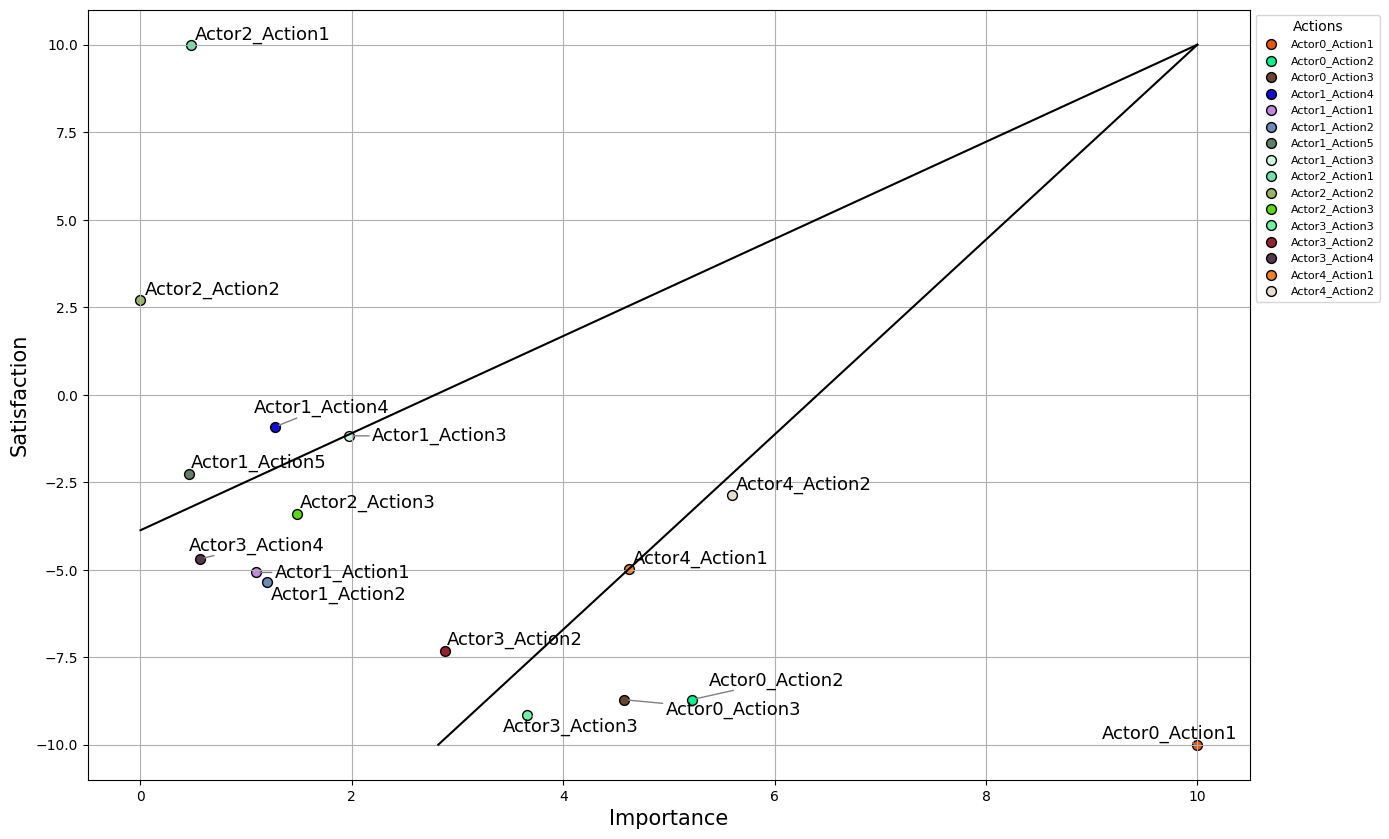

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

actions = sents_df['Action']
colors = np.random.rand(len(actions), 3)

importance = sents_df['importance']

satisfaction = sents_df['satisfaction']
opportunity = sents_df['opportunity']


plt.figure(figsize=(15,10))

for i, action in enumerate(actions):
  plt.scatter(importance[i], satisfaction[i], color=colors[i], label=action, s=50, edgecolors='black')

plt.legend(title='Actions',
           fontsize=8,
           title_fontsize = 10,
           loc =  'best',
           bbox_to_anchor=(1,1))
plt.xlabel('Importance', fontsize=15)
plt.ylabel('Satisfaction', fontsize=15)
xdata = [0,10]
ydata = [satisfaction.mean(),10]
plt.plot(xdata, ydata,'k-')
x_data = [importance.mean(),10]
y_data = [-10,10]
plt.plot(x_data, y_data,'k-')

texts = []
for i, action in enumerate(actions):
  texts.append(plt.text(importance[i], satisfaction[i], action, fontsize=13, ha='left'))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=1))
plt.grid(True)
plt.savefig('OpportunityArea.png', dpi= 300, bbox_inches="tight")
